# Titanic v2 — feature engineering, model comparison, group rule

**Plan**
1. Evaluate everything with *repeated stratified 5-fold cross-validation* instead of one 179-row split — single-split scores swing by ±2–3 points, so v1's "80.4%" was mostly noise.
2. Engineer features that carry real signal (Title, fare per person, ticket group size, cabin known).
3. Compare several models inside the same `Pipeline`, tune the best one.
4. Add the "woman-child group" rule: families tended to live or die together.
5. Fit on all 891 training passengers and write `submission_v2.csv`.

Reference points: predicting *female survives, male dies* already scores ~78.7%.

In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
train.shape, test.shape

((891, 12), (418, 11))

## 1. Feature engineering

Features are built on train + test **together** only for things that don't use the label
(e.g. how many people share a ticket — a test passenger's ticket-mates are visible in either file).
Nothing here looks at `Survived`, so there's no leakage.

| Feature | Why it helps |
|---|---|
| `Title` (Mr / Mrs / Miss / Master / Rare) | Encodes sex **and** age group. "Master" = boy, who were prioritised like women. |
| `FamilySize`, `IsAlone` | Very large families and people travelling alone both did worse. |
| `TicketCount` | Group size by shared ticket — catches friends/servants that SibSp/Parch miss. |
| `FarePP` | `Fare` is the **ticket total**, so divide by ticket group size to get the real price per person. |
| `HasCabin` | Cabin recorded mostly for 1st class / survivors' records — a wealth proxy. |

In [2]:
full = pd.concat([train, test], ignore_index=True)

title = full["Name"].str.extract(r",\s*([^\.]+)\.")[0]
title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
full["Title"] = title.where(title.isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")

full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
full["IsAlone"] = (full["FamilySize"] == 1).astype(int)
full["HasCabin"] = full["Cabin"].notna().astype(int)
full["TicketCount"] = full.groupby("Ticket")["Ticket"].transform("count")
full["FarePP"] = full["Fare"] / full["TicketCount"]

full["Title"].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

In [3]:
train_fe = full.iloc[: len(train)].copy()
test_fe = full.iloc[len(train):].copy()
y = train_fe["Survived"].astype(int)

train_fe.groupby("Title")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
Title,,
Master,0.575,40
Miss,0.703,185
Mr,0.157,517
Mrs,0.794,126
Rare,0.348,23


Title alone splits survival from ~16% (Mr) to ~58% (Master) and ~70–79% (Miss/Mrs).
Note how different "Master" is from "Mr" — that's the signal `Sex` alone can't see.

## 2. Evaluation setup

`RepeatedStratifiedKFold(5 folds × 3 repeats)` = 15 train/validate rounds. We report mean ± std.
The imputer and scaler live *inside* the pipeline, so they are re-fitted on each training fold only.

In [4]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

numeric = ["Pclass", "Age", "FarePP", "FamilySize", "IsAlone", "HasCabin", "TicketCount"]
categorical = ["Sex", "Title", "Embarked"]
features = numeric + categorical


def make_pipeline(classifier, num=numeric, cat=categorical, scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    preprocessor = ColumnTransformer([
        ("num", Pipeline(num_steps), num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
    ])
    return Pipeline([("preprocessor", preprocessor), ("classifier", classifier)])


def evaluate(pipeline, cols=features):
    scores = cross_val_score(pipeline, train_fe[cols], y, cv=cv)
    return scores.mean(), scores.std()

## 3. Baselines vs. new features

In [5]:
results = {}

results["Gender rule (female=1)"] = (((train_fe["Sex"] == "female").astype(int) == y).mean(), 0.0)

v1_num = ["Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize"]
results["v1: LogReg, old features"] = evaluate(
    make_pipeline(LogisticRegression(max_iter=1000), num=v1_num, cat=["Sex"]),
    cols=v1_num + ["Sex"],
)

models = {
    "LogReg, new features": make_pipeline(LogisticRegression(max_iter=1000)),
    "SVC (RBF), new features": make_pipeline(SVC()),
    "RandomForest, new features": make_pipeline(
        RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=2, random_state=0), scale=False),
    "GradientBoosting, new features": make_pipeline(
        GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0), scale=False),
}
for name, pipe in models.items():
    results[name] = evaluate(pipe)

results_df = pd.DataFrame(results, index=["cv_mean", "cv_std"]).T.round(4)
results_df

,cv_mean,cv_std
Gender rule (female=1),0.7868,0.0000
"v1: LogReg, old features",0.7886,0.0207
"LogReg, new features",0.8245,0.0176
"SVC (RBF), new features",0.8301,0.0175
"RandomForest, new features",0.8305,0.0184
"GradientBoosting, new features",0.8387,0.0198


Takeaways:
- Same LogReg, just better features: **~78.9% → ~82.5%**. Features matter more than the algorithm.
- Tree models (RF, GB) add another point because they learn interactions on their own —
  e.g. "female **and** 3rd class **and** big family" is much worse than "female" suggests.
- Trees don't need scaling (splits don't care about units), hence `scale=False`.

## 4. Tune gradient boosting

In [6]:
gb_pipe = make_pipeline(GradientBoostingClassifier(random_state=0), scale=False)
param_grid = {
    "classifier__n_estimators": [100, 200, 400],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
}
search = GridSearchCV(gb_pipe, param_grid, cv=cv, n_jobs=-1)
search.fit(train_fe[features], y)

print("best params:", search.best_params_)
print(f"best CV accuracy: {search.best_score_:.4f}")

best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 400, 'classifier__subsample': 1.0}
best CV accuracy: 0.8447


The tuned score is slightly optimistic (we picked the best of 54 combos on the same folds),
so treat anything within ~1 point of the untuned 83.9% as "about the same".

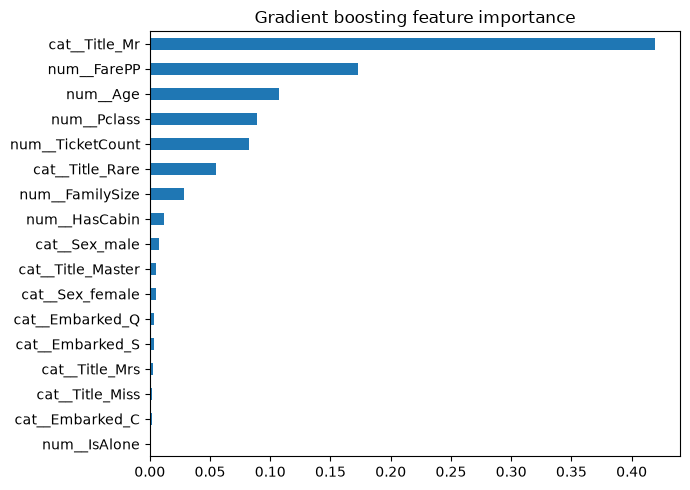

In [7]:
best_gb = search.best_estimator_.named_steps["classifier"]
feature_names = search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
importances = pd.Series(best_gb.feature_importances_, index=feature_names).sort_values()

importances.plot.barh(figsize=(7, 5), title="Gradient boosting feature importance")
plt.tight_layout()
plt.show()

## 5. Woman-child group (WCG) rule

The model treats passengers independently, but on the Titanic **families shared a fate**:
if the mother and daughters of a family died, the other women of that family usually did too;
if all the women and children of a family survived, the boy usually did too.

Rule, applied on top of the model's predictions:
- **Boy (Master)** whose family's women/children all survived → predict **survived**.
- **Female** whose family's women/children all died → predict **died**.

A "family group" = surname + class + ticket (minus last digit) + port + fare. Falls back to same ticket.

⚠️ The group rates use `Survived`, so inside CV they must be computed **only from the training fold**
— otherwise the validation passenger's own label leaks into their feature.

In [8]:
full["Surname"] = full["Name"].str.split(",").str[0]
full["Group"] = (
    full["Surname"] + "-" + full["Pclass"].astype(str) + "-" + full["Ticket"].str[:-1]
    + "-" + full["Embarked"].fillna("S") + "-" + full["Fare"].round(1).astype(str)
)
full["IsWomanOrChild"] = (full["Sex"] == "female") | (full["Title"] == "Master")

train_fe = full.iloc[: len(train)].copy()
test_fe = full.iloc[len(train):].copy()


def apply_wcg(known, target, predictions):
    """Correct predictions for `target` using survival of women/children in `known` (labelled rows)."""
    wc = known[known["IsWomanOrChild"]]
    group_rate = target["Group"].map(wc.groupby("Group")["Survived"].mean())
    group_rate = group_rate.fillna(target["Ticket"].map(wc.groupby("Ticket")["Survived"].mean()))

    corrected = pd.Series(predictions, index=target.index).copy()
    corrected[(target["Title"] == "Master") & (group_rate == 1)] = 1
    corrected[(target["Sex"] == "female") & (group_rate == 0)] = 0
    return corrected

In [9]:
final_pipe = search.best_estimator_
scores = {"GB tuned": [], "GB tuned + WCG": [], "Gender + WCG": []}

for fit_idx, val_idx in cv.split(train_fe, y):
    fit, val = train_fe.iloc[fit_idx], train_fe.iloc[val_idx]
    y_fit, y_val = y.iloc[fit_idx], y.iloc[val_idx]

    pipe = final_pipe.fit(fit[features], y_fit)
    pred = pipe.predict(val[features])
    gender = (val["Sex"] == "female").astype(int).values

    scores["GB tuned"].append((pred == y_val).mean())
    scores["GB tuned + WCG"].append((apply_wcg(fit, val, pred) == y_val).mean())
    scores["Gender + WCG"].append((apply_wcg(fit, val, gender) == y_val).mean())

pd.DataFrame({k: [np.mean(v), np.std(v)] for k, v in scores.items()}, index=["cv_mean", "cv_std"]).T.round(4)

,cv_mean,cv_std
GB tuned,0.8447,0.0211
GB tuned + WCG,0.8500,0.0212
Gender + WCG,0.8417,0.0257


The rule helps a little in CV, and it should help **more** on the real test set: a test passenger's
family members can be anywhere in all 891 labelled rows, whereas inside CV 20% of those rows are hidden.

## 6. Final model → submission

In [10]:
final_pipe.fit(train_fe[features], y)
test_pred = final_pipe.predict(test_fe[features])
test_pred_wcg = apply_wcg(train_fe, test_fe, test_pred)

changed = test_fe.loc[test_pred_wcg.values != test_pred, ["Name", "Sex", "Pclass", "Title"]].copy()
changed["model"] = test_pred[test_pred_wcg.values != test_pred]
changed["after_WCG"] = test_pred_wcg[test_pred_wcg.values != test_pred].values
changed

,Name,Sex,Pclass,Title,model,after_WCG
909,"Ilmakangas, Miss. Ida Livija",female,3,Miss,1,0
1175,"Rosblom, Miss. Salli Helena",female,3,Miss,1,0


In [11]:
submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"].astype(int),
    "Survived": test_pred_wcg.astype(int).values,
})
submission.to_csv("submission_v2.csv", index=False)

print(submission.shape, "| predicted survival rate:", round(submission["Survived"].mean(), 3),
      "| train survival rate:", round(y.mean(), 3))
submission.head()

(418, 2) | predicted survival rate: 0.366 | train survival rate: 0.384


,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1


## Summary

| Step | CV accuracy |
|---|---|
| Gender rule | ~78.7% |
| v1 LogReg (old features) | ~78.9% |
| LogReg + engineered features | ~82.5% |
| Gradient boosting (tuned) | ~84.5% |
| + woman-child group rule | ~85.0% |

Expect the **Kaggle leaderboard score to be ~2–4 points lower than CV** (test set is a slightly different
sample; ~0.78–0.81 is a strong honest score — the 1.0 entries use leaked answer lists).

Submit `submission_v2.csv` at *Competitions → Titanic → Submit Predictions*.

**Ideas to try next:** impute Age by Title (median per title) instead of global median;
a soft-voting ensemble of LogReg + SVC + GB; drop weak features and check whether CV holds.